<a href="https://colab.research.google.com/github/KarpagaKamaleshwaran/-sample/blob/main/Audience_Rating_ML_model_(Acc_52).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install xlrd>=2.0.1
import xlrd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer


In [6]:

# Load the dataset
data = pd.read_excel('/content/Rotten_Tomatoes_Movies3.xls')

In [7]:
# Step 2: Handle Missing Values
# Fill numeric columns with median
data['runtime_in_minutes'] = data['runtime_in_minutes'].fillna(data['runtime_in_minutes'].median())
data['audience_rating'] = data['audience_rating'].fillna(data['audience_rating'].median())

In [8]:
# Fill categorical columns with mode
data['genre'] = data['genre'].fillna(data['genre'].mode()[0])
data['directors'] = data['directors'].fillna(data['directors'].mode()[0])
data['writers'] = data['writers'].fillna(data['writers'].mode()[0])
data['cast'] = data['cast'].fillna(data['cast'].mode()[0])
data['studio_name'] = data['studio_name'].fillna(data['studio_name'].mode()[0])
data['in_theaters_date'] = pd.to_datetime(data['in_theaters_date'], errors='coerce').fillna(pd.Timestamp('1970-01-01'))
data['on_streaming_date'] = pd.to_datetime(data['on_streaming_date'], errors='coerce').fillna(pd.Timestamp('1970-01-01'))

In [9]:
# Step 3: Feature Engineering for Datetime Columns
data['in_theaters_year'] = data['in_theaters_date'].dt.year
data['in_theaters_month'] = data['in_theaters_date'].dt.month
data['in_theaters_day'] = data['in_theaters_date'].dt.day
data['in_theaters_dayofweek'] = data['in_theaters_date'].dt.dayofweek
data['on_streaming_year'] = data['on_streaming_date'].dt.year
data['on_streaming_month'] = data['on_streaming_date'].dt.month
data['on_streaming_day'] = data['on_streaming_date'].dt.day
data['on_streaming_dayofweek'] = data['on_streaming_date'].dt.dayofweek
data['days_to_streaming'] = (data['on_streaming_date'] - data['in_theaters_date']).dt.days

In [10]:
# Drop original datetime columns
data = data.drop(columns=['in_theaters_date', 'on_streaming_date'])


In [11]:
# Ensure categorical columns are strings
categorical_columns = ['genre', 'rating', 'directors', 'writers', 'cast', 'studio_name', 'tomatometer_status']
data[categorical_columns] = data[categorical_columns].astype(str)


In [12]:
# Step 4: Encode Categorical Features
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(data[categorical_columns])
onehot_df = pd.DataFrame(onehot_encoded, columns=onehot_encoder.get_feature_names_out(categorical_columns))

In [13]:
# Drop original categorical columns and concatenate one-hot encoded features
data = pd.concat([data.reset_index(drop=True), onehot_df.reset_index(drop=True)], axis=1)
data = data.drop(columns=categorical_columns)

In [14]:
# Step 5: Process Text Columns
# Vectorize 'movie_info'
vectorizer = TfidfVectorizer(max_features=100)
movie_info_features = vectorizer.fit_transform(data['movie_info'].fillna(''))
movie_info_df = pd.DataFrame(movie_info_features.toarray(), columns=vectorizer.get_feature_names_out())
data = pd.concat([data.reset_index(drop=True), movie_info_df.reset_index(drop=True)], axis=1)
data = data.drop(columns=['movie_info'])


In [15]:
# Step 6: Split the Data into Train and Test Sets
X = data.drop(columns=['audience_rating', 'movie_title', 'critics_consensus'])  # Drop target and non-informative columns
y = data['audience_rating']

In [16]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:

# Step 7: Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
# Step 8: Evaluate the Model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [19]:
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 196.50228112980767
R^2 Score: 0.5183309258439729


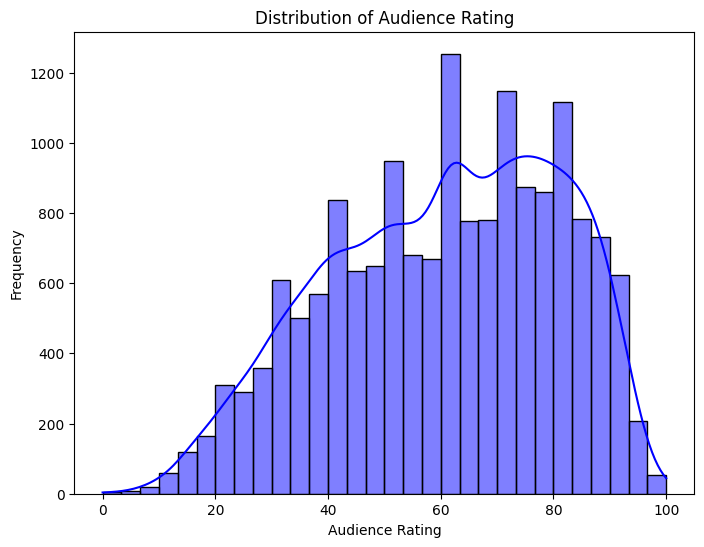

In [20]:
# Step 9: Visualization and Accuracy
# Visualization: Distribution of Audience Rating
plt.figure(figsize=(8, 6))
sns.histplot(data['audience_rating'], kde=True, bins=30, color='blue')
plt.title('Distribution of Audience Rating')
plt.xlabel('Audience Rating')
plt.ylabel('Frequency')
plt.show()

In [22]:
# Visualization: Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

<ipython-input-23-7f6adf4aaf72>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


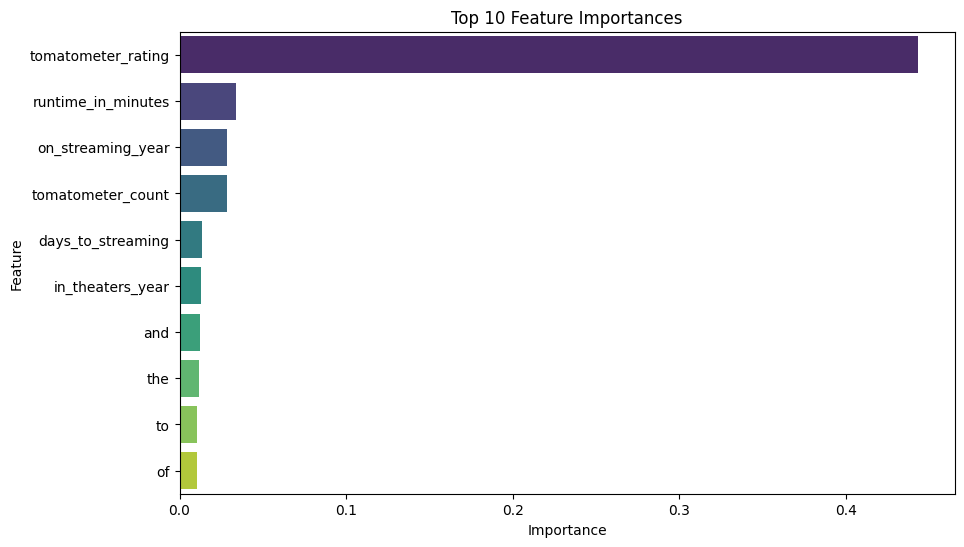

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [24]:
# Calculate accuracy in percentage
accuracy = r2 * 100
print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 51.83%
